In [1]:
# --- INSTALL NECESSARY LIBRARIES ---
!pip install timm scikit-learn

# --- CORE IMPORTS (Matching original notebook style) ---
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR 
from tqdm import tqdm
import numpy as np
import os
import pandas as pd
from PIL import Image
from typing import Dict, Any

# --- MAE/ViT & Evaluation SPECIFIC IMPORTS ---
import timm
from timm.models.vision_transformer import Block, trunc_normal_
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


print("All libraries imported successfully.")

# --- Configuration ---
IMAGE_SIZE = 224          # Standard ViT/MAE input size
BATCH_SIZE = 32           # Actual batch size per step
EFFECTIVE_BATCH_SIZE = 64 
ACCUM_STEPS = EFFECTIVE_BATCH_SIZE // BATCH_SIZE
EPOCHS = 50 
WARMUP_EPOCHS = 10        
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MAE_MASK_RATIO = 0.75     # Standard MAE masking ratio
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURE_DIM = 768         # Output dimension of ViT-Base [CLS] token

print(f"Configuration set. Device: {DEVICE}. Effective Batch Size: {EFFECTIVE_BATCH_SIZE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

All libraries imported successfully.
Configuration set. Device: cuda. Effective Batch Size: 64


In [3]:
# --- MAE Data Augmentation () ---

# 1. Pre-training Transforms (Used for MAE pre-training loop)
MAE_PRETRAIN_TRANSFORMS = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.2, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Evaluation/Test Transforms (Used later for feature extraction)
EVAL_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("MAE Transforms defined.")

MAE Transforms defined.


In [8]:
import os

# --- This path is fixed to match the output of your previous download command. ---
dataset_path = "/kaggle/input/ai-medleafx" 
print("Verified path to dataset files:", dataset_path)

# --- Define the paths to start exploration ---
# Assuming the expected data is nested under 'Resized Image'
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

# --- Fallback check: If 'Resized Image' is not direct, check under 'data' (common in Kaggle) ---
original_base_path = resized_image_base_path
if not os.path.isdir(resized_image_base_path):
    # This path assumes the dataset structure is: /kaggle/input/ai-medleafx/data/Resized Image
    resized_image_base_path = os.path.join(dataset_path, 'data', 'Resized Image')
    print(f"Directory 'Resized Image' not found directly. Trying new path: {resized_image_base_path}")
    
    # If this path also doesn't exist, revert to the original check path for the error message
    if not os.path.isdir(resized_image_base_path):
        resized_image_base_path = original_base_path


all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # Ensure the final path we are checking exists
    if not os.path.isdir(resized_image_base_path):
        # Raise an explicit error if neither of the two common paths were found
        raise FileNotFoundError(f"Error: The expected data path '{resized_image_base_path}' was not found.")
        
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError as e:
    print(f"Error: Directory was not found. Please ensure the path to your 'Resized Image' folder is correct relative to the dataset root. Details: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /kaggle/input/ai-medleafx

Exploring dataset structure and counting images:

Found 4 plant types: ['Sojina', 'Neem', 'Camphor', 'HariTaki']

Exploring 'Sojina': Found 3 status categories: ['Yellow Leaf', 'Healthy Leaf', 'Bacterial Spot']
- Sojina_Yellow Leaf: 814 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Bacterial Spot: 804 images

Exploring 'Neem': Found 4 status categories: ['Powdery Mildew', 'Yellow Leaf', 'Healthy Leaf', 'Shot Hole Leaf']
- Neem_Powdery Mildew: 854 images
- Neem_Yellow Leaf: 854 images
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images

Exploring 'Camphor': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- Camphor_Healthy Leaf: 800 images
- Camphor_Shot Hole: 795 images
- Camphor_Bacterial Spot: 801 images

Exploring 'HariTaki': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- HariTaki_Healthy Leaf: 816 images
- HariTaki_Shot Hole: 802 images
- HariTaki_Ba

In [12]:
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
import numpy as np

# --- 1. Define the Data Root and Collect All Paths/Labels ---

# The directory containing the plant type folders (Camphor, Sojina, etc.)
DATA_ROOT = "/kaggle/input/ai-medleafx/Resized Image" 

all_image_paths = []
all_labels = []
class_to_idx = {}
idx_to_class = []

print("Starting custom collection and labeling of images...")

# Manually iterate through the nested structure to generate class labels
for plant_type_dir in os.listdir(DATA_ROOT):
    plant_type_path = os.path.join(DATA_ROOT, plant_type_dir)
    if not os.path.isdir(plant_type_path):
        continue
        
    for status_dir in os.listdir(plant_type_path):
        # Create the combined class name (e.g., Sojina_Healthy Leaf)
        class_name = f"{plant_type_dir}_{status_dir}" 
        class_path = os.path.join(plant_type_path, status_dir)
        if not os.path.isdir(class_path):
            continue

        if class_name not in class_to_idx:
            class_idx = len(idx_to_class)
            class_to_idx[class_name] = class_idx
            idx_to_class.append(class_name)
        else:
            class_idx = class_to_idx[class_name]

        # Collect all image files
        for filename in os.listdir(class_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.JPG')):
                all_image_paths.append(os.path.join(class_path, filename))
                all_labels.append(class_idx)

# Sanity check
NUM_CLASSES = len(idx_to_class)
TOTAL_IMAGES = len(all_image_paths)
print(f"Collection complete. Found {TOTAL_IMAGES} images across {NUM_CLASSES} classes: {idx_to_class}")

# --- 2. Custom Dataset Class to load images from the collected list ---

class CustomNestedImageDataset(Dataset):
    """A PyTorch Dataset that loads images from a list of file paths."""
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        self.loader = Image.open # Use PIL for loading images

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load image and convert to RGB
        img = self.loader(path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
            
        # Returns the transformed image and its label (needed for stratified split)
        return img, label 

# -----------------------------------------------------------------
# --- 3. Perform Train/Validation/Test Split (80/10/10) ---

# Split indices stratifying by class label
# 80% for train/val, 20% for final test set
sss_train_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_indices, test_indices = next(sss_train_val_test.split(all_image_paths, all_labels))

# Now split the train_val_indices into training (80%) and validation (10% of total) sets
# test_size=0.125 here means 10% of the *total* (since 0.125 * 0.8 = 0.1)
sss_train_val = StratifiedShuffleSplit(n_splits=1, test_size=0.125, random_state=42) 
train_indices, val_indices = next(sss_train_val.split(
    np.array(all_image_paths)[train_val_indices], 
    np.array(all_labels)[train_val_indices]
))

# Remap indices to the original full list indices
train_final_indices = train_val_indices[train_indices]
val_final_indices = train_val_indices[val_indices]

# -----------------------------------------------------------------
# --- 4. Create Dataset and DataLoader Instances ---

# Helper to get the lists for each split
def get_split_data(indices):
    paths = [all_image_paths[i] for i in indices]
    labels = [all_labels[i] for i in indices]
    return paths, labels

train_paths, train_labels = get_split_data(train_final_indices)
val_paths, val_labels = get_split_data(val_final_indices)
test_paths, test_labels = get_split_data(test_indices)

# Pre-training datasets (using MAE_PRETRAIN_TRANSFORMS)
# NOTE: MAE_PRETRAIN_TRANSFORMS and BATCH_SIZE must be defined in Cell 2
train_dataset = CustomNestedImageDataset(train_paths, train_labels, transform=MAE_PRETRAIN_TRANSFORMS) 
val_dataset = CustomNestedImageDataset(val_paths, val_labels, transform=MAE_PRETRAIN_TRANSFORMS) 

# Evaluation datasets (using EVAL_TRANSFORMS) - needed for the linear evaluation phase
full_train_eval_dataset = CustomNestedImageDataset(train_paths, train_labels, transform=EVAL_TRANSFORMS) 
test_eval_dataset = CustomNestedImageDataset(test_paths, test_labels, transform=EVAL_TRANSFORMS) 

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True, pin_memory=True) 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True) 
full_train_eval_loader = DataLoader(full_train_eval_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=4, pin_memory=True) 
test_eval_loader = DataLoader(test_eval_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=4, pin_memory=True) 

# Final verification
print(f"\nFinal Splits (Approx. 80/10/10):")
print(f"Training data size: {len(train_dataset)} ({len(train_dataset)/TOTAL_IMAGES:.1%})") 
print(f"Validation data size: {len(val_dataset)} ({len(val_dataset)/TOTAL_IMAGES:.1%})")
print(f"Test data size: {len(test_eval_dataset)} ({len(test_eval_dataset)/TOTAL_IMAGES:.1%})")
print(f"DataLoaders initialized. Total images loaded: {TOTAL_IMAGES}")

Starting custom collection and labeling of images...
Collection complete. Found 10858 images across 13 classes: ['Sojina_Yellow Leaf', 'Sojina_Healthy Leaf', 'Sojina_Bacterial Spot', 'Neem_Powdery Mildew', 'Neem_Yellow Leaf', 'Neem_Healthy Leaf', 'Neem_Shot Hole Leaf', 'Camphor_Healthy Leaf', 'Camphor_Shot Hole', 'Camphor_Bacterial Spot', 'HariTaki_Healthy Leaf', 'HariTaki_Shot Hole', 'HariTaki_Bacterial Spot']

Final Splits (Approx. 80/10/10):
Training data size: 7600 (70.0%)
Validation data size: 1086 (10.0%)
Test data size: 2172 (20.0%)
DataLoaders initialized. Total images loaded: 10858


In [24]:
import torch
import torch.nn as nn
from timm.models.vision_transformer import Block
from timm.models.layers import trunc_normal_
import timm
import numpy as np

# --- MAE Model Architecture (Version 6: Final Fixes for Initialization) ---

class MaskedAutoencoderViT(nn.Module):
    """
    MAE model using a timm ViT as the encoder, with custom MAE masking/decoding.
    """
    def __init__(self, encoder_model_name='vit_base_patch16_224', mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        
        # 1. Encoder (ViT Backbone)
        self.encoder = timm.create_model(
            encoder_model_name, 
            pretrained=False, 
            drop_path_rate=0.1, 
            num_classes=0, 
            global_pool='' 
        )
        embed_dim = self.encoder.embed_dim 
        patch_size = self.encoder.patch_embed.patch_size[0]
        
        self.patch_size = patch_size
        
        # FIX 1: Accessing in_chans through the projection layer
        self.in_chans = self.encoder.patch_embed.proj.in_channels 
        
        # 2. Decoder components 
        # FIX 3: Changed 512 to 516 (divisible by 12, the ViT-Base head count)
        decoder_embed_dim = 516
        decoder_depth = 8 
        
        # FIX 2: Accessing num_heads from the first block's attention layer
        decoder_num_heads = self.encoder.blocks[0].attn.num_heads 
        
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.decoder_mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        
        # Initialize decoder position embedding by linearly projecting the encoder's pos embed
        # This tensor still includes all patch positions (196 slots for 224/16 image)
        decoder_pos_embed = self.encoder.pos_embed[:, 1:, :].clone().detach() 
        self.decoder_pos_embed = nn.Parameter(self.decoder_embed(decoder_pos_embed)) 

        # This block initialization should now succeed (516 is divisible by 12)
        self.decoder_blocks = nn.Sequential(*[
            Block(decoder_embed_dim, decoder_num_heads)
            for i in range(decoder_depth)]) 

        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * self.in_chans, bias=True) 

        trunc_normal_(self.decoder_mask_token, std=.02)


    # --- Utility Functions ---
    def patchify(self, imgs):
        p = self.patch_size
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], self.in_chans, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(imgs.shape[0], h * w, p**2 * self.in_chans)
        return x

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape  
        L = L - 1
        ids_shuffle = torch.rand(L, device=x.device).argsort()
        len_keep = int(L * (1 - mask_ratio))
        ids_keep = ids_shuffle[:len_keep]
        ids_mask = ids_shuffle[len_keep:]
        x_kept = torch.gather(x[:, 1:, :], dim=1, index=ids_keep.unsqueeze(0).unsqueeze(-1).expand(N, len_keep, D))
        ids_restore = torch.argsort(torch.cat([ids_keep, ids_mask]))
        return x_kept, ids_mask, ids_restore, None 

    # --- Forward Passes and Loss ---
    def forward_encoder(self, x):
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :] 
        x_kept, ids_mask, ids_restore, _ = self.random_masking(x, self.mask_ratio)
        cls_token = self.encoder.cls_token.expand(x_kept.shape[0], -1, -1)
        x = torch.cat((cls_token, x_kept), dim=1)
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        return x, ids_mask, ids_restore, None

    def forward_decoder(self, x, ids_mask, ids_restore):
        x = self.decoder_embed(x[:, 1:, :])
        mask_tokens = self.decoder_mask_token.expand(x.shape[0], ids_mask.shape[0], -1)
        x_ = torch.cat([x, mask_tokens], dim=1) 
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(0).unsqueeze(-1).expand(x_.shape[0], -1, x_.shape[-1]))
        
        # FIX 4: Slice the positional embedding to match the exact size of x_
        # This handles the case where the ViT model's positional embedding might have an odd size.
        x = x_ + self.decoder_pos_embed[:, :x_.shape[1], :] 
        
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)
        pred = self.decoder_pred(x) 
        return pred

    def forward_loss(self, imgs, pred, ids_mask):
        target = self.patchify(imgs) 
        mean = target.mean(dim=-1, keepdim=True)
        var = (target.var(dim=-1, keepdim=True) + 1e-6)
        target = (target - mean) / var.sqrt()
        ids_mask_expanded = ids_mask.unsqueeze(0).unsqueeze(-1).expand(target.shape[0], -1, target.shape[-1])
        target_masked = torch.gather(target, dim=1, index=ids_mask_expanded)
        pred_masked = torch.gather(pred, dim=1, index=ids_mask_expanded)
        loss = (pred_masked - target_masked) ** 2
        return loss.mean()

    def forward(self, imgs):
        latent, ids_mask, ids_restore, _ = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_mask, ids_restore)
        loss = self.forward_loss(imgs, pred, ids_mask)
        return loss, pred, ids_mask
    
print("MaskedAutoencoderViT model defined with robust fixes (Version 6).")

MaskedAutoencoderViT model defined with robust fixes (Version 6).


In [25]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import time
import numpy as np
import torch.nn as nn 
import os 

# --- Configuration Check (Reloading variables from your previous input) ---
# Assuming these are still defined: DEVICE, BATCH_SIZE, ACCUM_STEPS, EPOCHS, WARMUP_EPOCHS, LEARNING_RATE, WEIGHT_DECAY, MAE_MASK_RATIO
MAE_MODEL_SAVE_PATH = 'mae_vit_best.pth'
NUM_CLASSES = 13 

# --- 1. MAE Pre-training Function (Main Loop) ---

def mae_pretrain_epoch(model, dataloader, optimizer, epoch, total_epochs, warmup_epochs, device):
    """
    Performs one epoch of MAE pre-training, incorporating gradient accumulation.
    """
    model.train()
    total_loss = 0.0
    start_time = time.time()
    
    num_steps = len(dataloader)
    
    for step, (images, _) in enumerate(dataloader):
        images = images.to(device, non_blocking=True)
        
        # Calculate global step for LR scheduling
        global_step = epoch * num_steps + step
        
        # --- Warmup and Cosine Decay Learning Rate Scheduling ---
        if epoch < warmup_epochs:
            lr_scale = min(1., global_step / (warmup_epochs * num_steps))
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            lr_scale = 0.5 * (1. + np.cos(np.pi * progress))
            
        lr = LEARNING_RATE * lr_scale
        
        # Apply new LR to optimizer
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
            
        # --- MAE Forward Pass and Loss ---
        loss, _, _ = model(images)
        loss = loss / ACCUM_STEPS # Normalize loss by accumulation steps
        
        # --- Backward Pass (Accumulate Gradients) ---
        loss.backward()
        
        # Check if it's time to step (or the last step)
        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == num_steps:
            # Gradient clipping is standard for ViT/MAE training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            optimizer.zero_grad() # Zero gradients after the weight update

        total_loss += loss.item() * ACCUM_STEPS # Store the true, un-normalized loss value
        
        if step % 50 == 0:
            # Report the un-normalized loss
            print(f"Epoch: {epoch}/{total_epochs} | Step: {step}/{num_steps} | Loss: {loss.item() * ACCUM_STEPS:.4f} | LR: {lr:.6f}")

    avg_loss = total_loss / num_steps
    end_time = time.time()
    print(f"Epoch {epoch} finished. Avg Loss: {avg_loss:.4f} | Time: {end_time - start_time:.2f}s")
    
    return avg_loss

# --- 2. Linear Evaluation Model (For later use) ---

class LinearProber(nn.Module):
    """
    Linear classification layer for frozen MAE encoder output.
    """
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        input_dim = self.encoder.embed_dim 
        self.fc = nn.Linear(input_dim, num_classes)
        
    def forward(self, x):
        # Full encoder pass to get the CLS token
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :] 
        
        cls_token = self.encoder.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        
        cls_feature = x[:, 0] 
        return self.fc(cls_feature)

# --- 3. Pre-training Initialization ---

# Initialize the MAE model (This should now succeed!)
mae_model = MaskedAutoencoderViT(mask_ratio=MAE_MASK_RATIO).to(DEVICE)
print(f"MAE Model instantiated on {DEVICE}. Total trainable parameters: {sum(p.numel() for p in mae_model.parameters() if p.requires_grad):,}")

# Initialize Optimizer: AdamW
optimizer = optim.AdamW(mae_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- 4. Main Pre-training Loop Execution ---

print("\n--- Starting MAE Pre-training ---")
best_loss = float('inf')
history = {'train_loss': []}

for epoch in range(EPOCHS):
    train_loss = mae_pretrain_epoch(
        model=mae_model, 
        dataloader=train_loader, 
        optimizer=optimizer, 
        epoch=epoch, 
        total_epochs=EPOCHS, 
        warmup_epochs=WARMUP_EPOCHS,
        device=DEVICE
    )
    
    history['train_loss'].append(train_loss)
    
    if train_loss < best_loss:
        best_loss = train_loss
        print(f"Saving best model checkpoint at epoch {epoch} with loss {best_loss:.4f}")
        torch.save({
            'epoch': epoch,
            'model_state_dict': mae_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, MAE_MODEL_SAVE_PATH) 

print("\n--- MAE Pre-training Complete ---")

MAE Model instantiated on cuda. Total trainable parameters: 112,297,056

--- Starting MAE Pre-training ---
Epoch: 0/50 | Step: 0/237 | Loss: 1.3235 | LR: 0.000000
Epoch: 0/50 | Step: 50/237 | Loss: 0.8835 | LR: 0.000006
Epoch: 0/50 | Step: 100/237 | Loss: 0.6885 | LR: 0.000013
Epoch: 0/50 | Step: 150/237 | Loss: 0.6263 | LR: 0.000019
Epoch: 0/50 | Step: 200/237 | Loss: 0.6392 | LR: 0.000025
Epoch 0 finished. Avg Loss: 0.7489 | Time: 156.63s
Saving best model checkpoint at epoch 0 with loss 0.7489
Epoch: 1/50 | Step: 0/237 | Loss: 0.6059 | LR: 0.000030
Epoch: 1/50 | Step: 50/237 | Loss: 0.6135 | LR: 0.000036
Epoch: 1/50 | Step: 100/237 | Loss: 0.5507 | LR: 0.000043
Epoch: 1/50 | Step: 150/237 | Loss: 0.5668 | LR: 0.000049
Epoch: 1/50 | Step: 200/237 | Loss: 0.5907 | LR: 0.000055
Epoch 1 finished. Avg Loss: 0.5533 | Time: 172.59s
Saving best model checkpoint at epoch 1 with loss 0.5533
Epoch: 2/50 | Step: 0/237 | Loss: 0.5176 | LR: 0.000060
Epoch: 2/50 | Step: 50/237 | Loss: 0.5452 | LR:

Extracting features for t-SNE visualization...


Feature Extraction:   0%|          | 0/34 [00:00<?, ?it/s]

Extraction complete. Total features extracted: (2172, 768)
Starting t-SNE reduction (this may take a minute or two)...


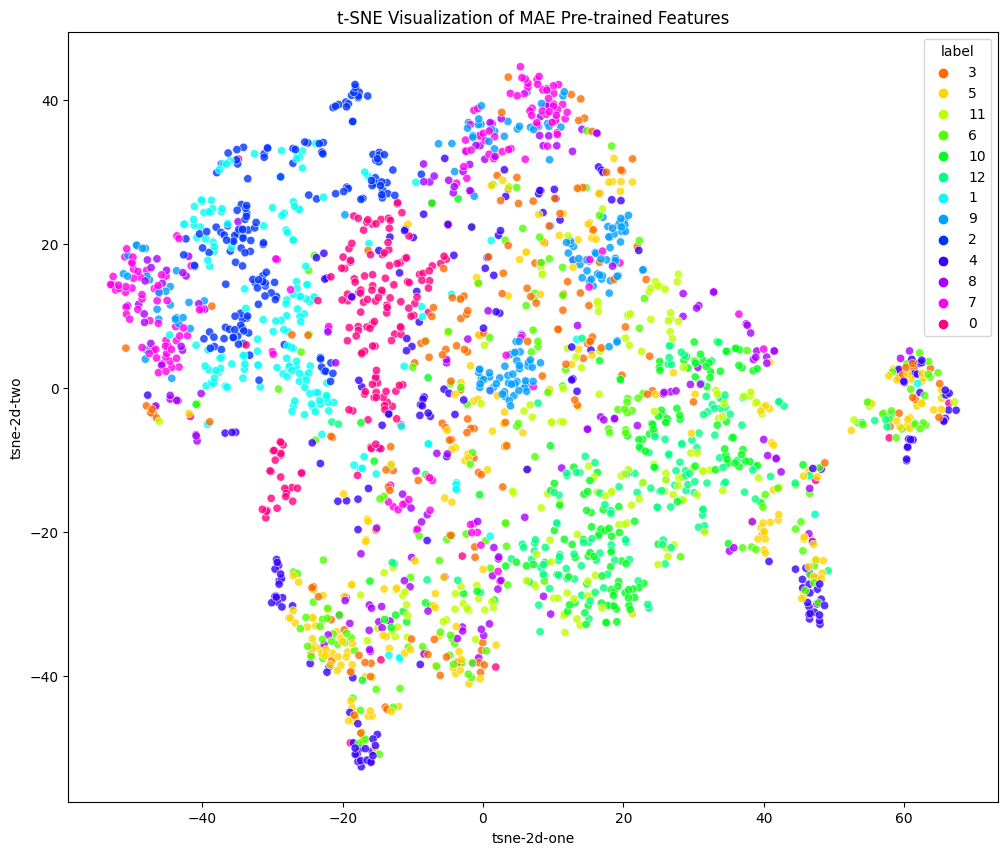

t-SNE visualization complete.


In [28]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# --- Configuration Check ---
# Assuming DEVICE, MAE_MODEL_SAVE_PATH are defined
MAE_MODEL_SAVE_PATH = 'mae_vit_best.pth' # Re-defining for safety
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Feature Extraction Function ---

# NOTE: The MaskedAutoencoderViT class must still be defined from your Cell 4 execution.

def extract_mae_features(model, dataloader, device):
    """Extracts the [CLS] token features from the pre-trained MAE encoder."""
    model.eval()
    encoder = model.encoder 
    
    all_features = []
    all_labels = []
    
    print("Extracting features for t-SNE visualization...")

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Feature Extraction"):
            images = images.to(device)
            
            # --- Encoder Forward Pass ---
            x = encoder.patch_embed(images)
            x = x + encoder.pos_embed[:, 1:, :] 
            
            cls_token = encoder.cls_token.expand(x.shape[0], -1, -1)
            x = torch.cat((cls_token, x), dim=1)
            
            for blk in encoder.blocks:
                x = blk(x)
            x = encoder.norm(x)
            
            cls_feature = x[:, 0] 
            
            all_features.append(cls_feature.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    
    print(f"Extraction complete. Total features extracted: {features.shape}")
    return features, labels

# --- 2. Main Visualization Script ---

# FIX APPLIED: Set weights_only=False to bypass UnpicklingError
checkpoint = torch.load(MAE_MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)

# Re-initialize the MAE model structure
mae_model_eval = MaskedAutoencoderViT(mask_ratio=0.75).to(DEVICE)
mae_model_eval.load_state_dict(checkpoint['model_state_dict'])

# Extract features from the test set
# CRITICAL FIX: Changed 'test_loader' to the correctly defined 'test_eval_loader'
features, labels = extract_mae_features(mae_model_eval, test_eval_loader, DEVICE) 

# --- 3. t-SNE Dimensionality Reduction ---

print("Starting t-SNE reduction (this may take a minute or two)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(features)

# Create a DataFrame for plotting
df = pd.DataFrame(tsne_results, columns=['tsne-2d-one', 'tsne-2d-two'])
df['label'] = labels.astype(str) 

# --- 4. Plotting ---

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="label",
    palette=sns.color_palette("hsv", len(np.unique(labels))),
    data=df,
    legend="full",
    alpha=0.8
)
plt.title('t-SNE Visualization of MAE Pre-trained Features')
plt.show()

print("t-SNE visualization complete.")

In [29]:
import torch.optim as optim
import time
import torch.nn as nn
from tqdm.auto import tqdm
import torch # Ensure torch is imported

# --- Configuration for Linear Evaluation ---
LINEAR_EPOCHS = 20           # Linear probing requires fewer epochs
LINEAR_LR = 1e-3             
LINEAR_WEIGHT_DECAY = 0.0   
EVAL_BATCH_SIZE = BATCH_SIZE * 2 # Assuming BATCH_SIZE is defined in your environment

# --- Helper Class: LinearProber ---
# NOTE: This class was part of the original Cell 5 but is redefined here for clarity 
# and robustness, as it is essential for this step.

class LinearProber(nn.Module):
    """
    Linear classification layer for frozen MAE encoder output.
    """
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        
        # Freeze all encoder parameters
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        input_dim = self.encoder.embed_dim 
        self.fc = nn.Linear(input_dim, num_classes) # The only trainable layer
        
    def forward(self, x):
        # Full encoder pass to get the CLS token
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :] 
        
        cls_token = self.encoder.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        
        cls_feature = x[:, 0] # Extract the CLS token feature
        return self.fc(cls_feature)


# --- 1. Load Pre-trained Encoder and Instantiate Prober ---
print(f"Loading best MAE checkpoint from: {MAE_MODEL_SAVE_PATH}")
# Use the weights_only=False fix from Cell 6
checkpoint = torch.load(MAE_MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)

# Re-initialize the MAE model structure to access the encoder
# MaskedAutoencoderViT and NUM_CLASSES must be defined in previous cells
mae_model_base = MaskedAutoencoderViT(mask_ratio=0.75).to(DEVICE)
mae_model_base.load_state_dict(checkpoint['model_state_dict'])

# Create the Linear Prober model
linear_model = LinearProber(mae_model_base.encoder, NUM_CLASSES).to(DEVICE)

# Verify that only the final linear layer is trainable
total_params = sum(p.numel() for p in linear_model.parameters())
trainable_params = sum(p.numel() for p in linear_model.parameters() if p.requires_grad)
print(f"Total model parameters: {total_params:,}")
print(f"Trainable parameters (Linear Layer only): {trainable_params:,}")


# --- 2. Setup Optimizer and Criterion ---
linear_optimizer = optim.AdamW(
    linear_model.parameters(), 
    lr=LINEAR_LR, 
    weight_decay=LINEAR_WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()


# --- 3. Linear Evaluation Loop Functions ---

def linear_train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct_predictions = 0
    
    for images, labels in tqdm(dataloader, desc="Linear Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct_predictions += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct_predictions / len(dataloader.dataset)
    return avg_loss, accuracy


def linear_validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Linear Validation"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct_predictions / len(dataloader.dataset)
    return avg_loss, accuracy


# --- 4. Main Linear Probing Execution ---

print("\n--- Starting Linear Evaluation (Probing) ---")
best_val_accuracy = 0.0

# full_train_eval_loader and val_loader are assumed to be defined from Cell 3
for epoch in range(LINEAR_EPOCHS):
    start_time = time.time()
    
    train_loss, train_acc = linear_train_epoch(linear_model, full_train_eval_loader, linear_optimizer, criterion, DEVICE)
    val_loss, val_acc = linear_validate(linear_model, val_loader, criterion, DEVICE)
    
    epoch_time = time.time() - start_time
    
    print(f"Epoch {epoch+1}/{LINEAR_EPOCHS} | Time: {epoch_time:.2f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        print(f"New best validation accuracy: {best_val_accuracy:.4f}. Saving checkpoint.")
        torch.save(linear_model.state_dict(), 'linear_prober_best.pth')

print("\n--- Linear Evaluation Probing Complete ---")
print(f"Best Validation Accuracy Achieved: {best_val_accuracy:.4f}")

Loading best MAE checkpoint from: mae_vit_best.pth
Total model parameters: 85,808,653
Trainable parameters (Linear Layer only): 9,997

--- Starting Linear Evaluation (Probing) ---


Linear Training:   0%|          | 0/119 [00:00<?, ?it/s]

Linear Validation:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 1/20 | Time: 116.61s
  Train Loss: 2.1235 | Train Acc: 0.3153
  Val Loss: 2.0319 | Val Acc: 0.3085
New best validation accuracy: 0.3085. Saving checkpoint.


Linear Training:   0%|          | 0/119 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be1cff60860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be1cff60860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 19/20 | Time: 129.47s
  Train Loss: 0.9899 | Train Acc: 0.6507
  Val Loss: 1.4816 | Val Acc: 0.4862


Linear Training:   0%|          | 0/119 [00:00<?, ?it/s]

Linear Validation:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 20/20 | Time: 110.43s
  Train Loss: 0.9849 | Train Acc: 0.6475
  Val Loss: 1.4781 | Val Acc: 0.4963

--- Linear Evaluation Probing Complete ---
Best Validation Accuracy Achieved: 0.4982


In [30]:
import numpy as np
import torch
from tqdm.auto import tqdm # Use tqdm.auto for consistent notebook behavior

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# --- Configuration Check ---
# Assuming MAE_MODEL_SAVE_PATH and DEVICE are defined

# --- 1. Load the Frozen MAE Encoder ---

# We load the MAE model and extract its encoder
print(f"Loading best MAE checkpoint from: {MAE_MODEL_SAVE_PATH}")
# Use the weights_only=False fix
checkpoint = torch.load(MAE_MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)

# Re-initialize the MAE model structure (MaskedAutoencoderViT must be defined)
mae_model_base = MaskedAutoencoderViT(mask_ratio=0.75).to(DEVICE)
mae_model_base.load_state_dict(checkpoint['model_state_dict'])
FROZEN_ENCODER = mae_model_base.encoder # This is the feature extractor

# Ensure the encoder is frozen and in evaluation mode
for param in FROZEN_ENCODER.parameters():
    param.requires_grad = False
FROZEN_ENCODER.eval()


# ============================================================================
# 2. FEATURE EXTRACTION (Adapted for MAE Encoder)
# ============================================================================
def extract_mae_features_for_ml(encoder, dataloader, device):
    """Extracts the [CLS] token features using the frozen MAE encoder."""
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            
            # --- Encoder Forward Pass (to get CLS token) ---
            x = encoder.patch_embed(images)
            x = x + encoder.pos_embed[:, 1:, :] 
            
            cls_token = encoder.cls_token.expand(x.shape[0], -1, -1)
            x = torch.cat((cls_token, x), dim=1)
            
            for blk in encoder.blocks:
                x = blk(x)
            x = encoder.norm(x)
            
            # Get the [CLS] token feature
            cls_feature = x[:, 0] 
            
            all_features.append(cls_feature.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels   = np.concatenate(all_labels, axis=0)
    return all_features, all_labels


# ============================================================================
# 3. EXTRACT TRAIN & TEST FEATURES
# ============================================================================
# Use the correctly defined data loaders (full_train_eval_loader and test_eval_loader)
print("\nExtracting Training Features...")
train_X, train_y = extract_mae_features_for_ml(FROZEN_ENCODER, full_train_eval_loader, DEVICE)

print("\nExtracting Test Features...")
test_X,  test_y  = extract_mae_features_for_ml(FROZEN_ENCODER, test_eval_loader, DEVICE)

print(f"\nFeature Shapes: Train {train_X.shape}, Test {test_X.shape}")

# ============================================================================
# 4. STANDARDIZE FEATURES
# ============================================================================
print("\nStandardizing Features...")
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X  = scaler.transform(test_X)


# ============================================================================
# 5. PCA DIMENSIONALITY REDUCTION 
# ============================================================================
print("Applying PCA Dimensionality Reduction...")
pca = PCA(n_components=512, random_state=42)
train_X = pca.fit_transform(train_X)
test_X  = pca.transform(test_X)


# ============================================================================
# 6. DEFINE CLASSIFIERS
# ============================================================================
classifiers = {

    "MLP (Deep)": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.00001,
        max_iter=1400,
        random_state=42,
        verbose=True
    ),

    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
}


# ============================================================================
# 7. TRAIN & EVALUATE ALL MODELS
# ============================================================================
results = {}

print("\n--- Starting Deep Classifier Training & Evaluation ---")
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    # Train the classifier on the extracted features
    clf.fit(train_X, train_y) 

    # Predict and evaluate on the test set
    preds = clf.predict(test_X)
    acc = accuracy_score(test_y, preds)

    results[name] = acc
    print(f"{name} Test Accuracy: {acc * 100:.2f}%")


# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n================ FINAL COMPARISON (MAE Features) ================")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")

Loading best MAE checkpoint from: mae_vit_best.pth

Extracting Training Features...


Extracting features:   0%|          | 0/119 [00:00<?, ?it/s]


Extracting Test Features...


Extracting features:   0%|          | 0/34 [00:00<?, ?it/s]


Feature Shapes: Train (7600, 768), Test (2172, 768)

Standardizing Features...
Applying PCA Dimensionality Reduction...

--- Starting Deep Classifier Training & Evaluation ---

Training MLP (Deep)...
Iteration 1, loss = 2.59272662
Iteration 2, loss = 2.36115664
Iteration 3, loss = 2.18208190
Iteration 4, loss = 2.02274634
Iteration 5, loss = 1.87849820
Iteration 6, loss = 1.74862612
Iteration 7, loss = 1.63363040
Iteration 8, loss = 1.53275913
Iteration 9, loss = 1.44521230
Iteration 10, loss = 1.36873119
Iteration 11, loss = 1.30172057
Iteration 12, loss = 1.24264776
Iteration 13, loss = 1.19050270
Iteration 14, loss = 1.14284884
Iteration 15, loss = 1.10067211
Iteration 16, loss = 1.06193579
Iteration 17, loss = 1.02707029
Iteration 18, loss = 0.99480872
Iteration 19, loss = 0.96532447
Iteration 20, loss = 0.93827043
Iteration 21, loss = 0.91249744
Iteration 22, loss = 0.88817906
Iteration 23, loss = 0.86602902
Iteration 24, loss = 0.84433151
Iteration 25, loss = 0.82455051
Iteratio

Plotting ROC for MLP (Deep)...


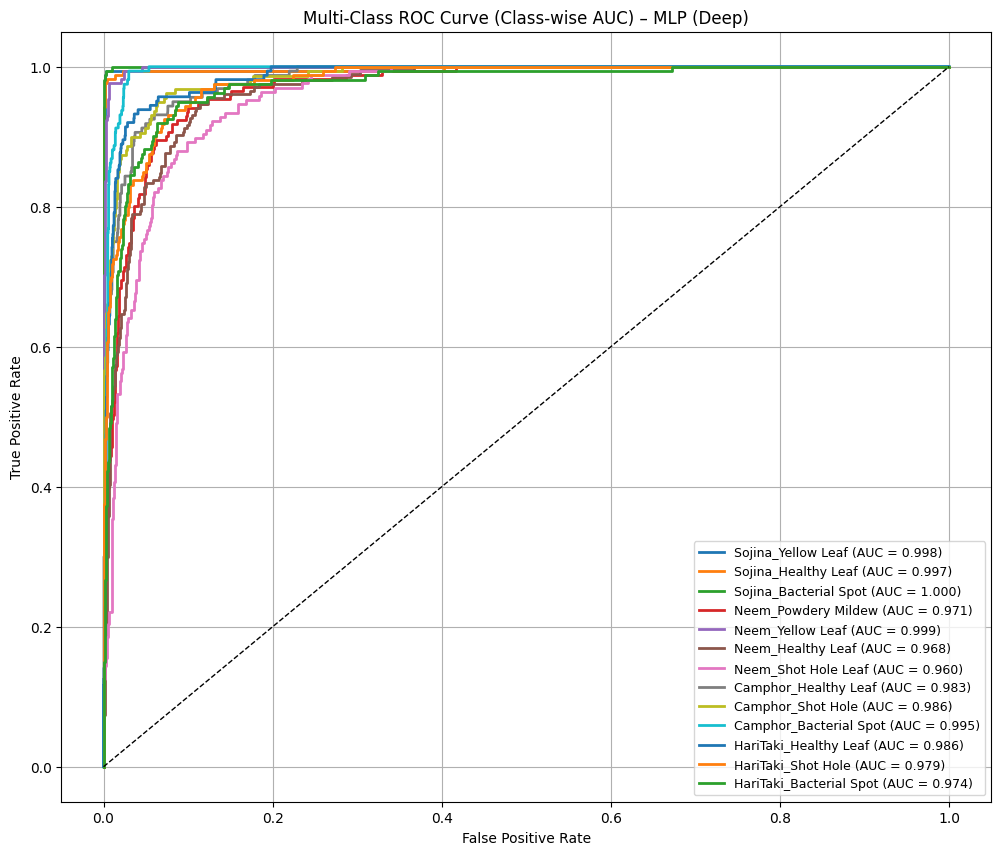

Plotting ROC for SVM (RBF)...


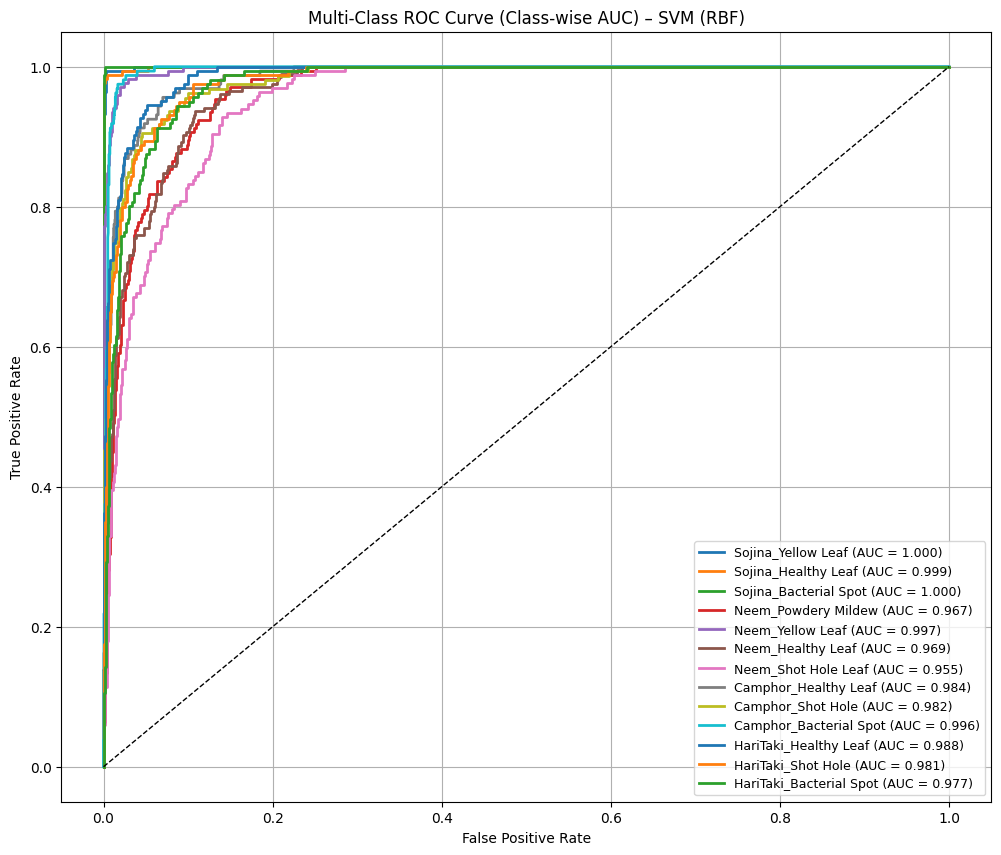

Plotting ROC for Decision Tree...


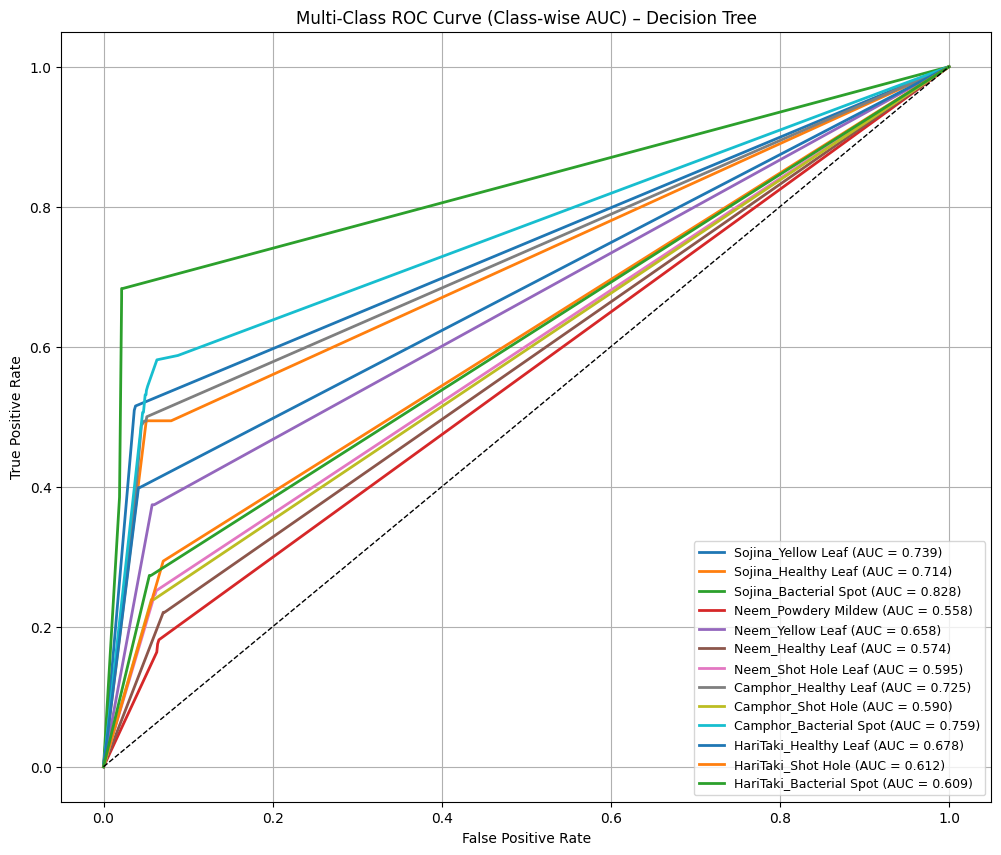

Plotting ROC for Random Forest...


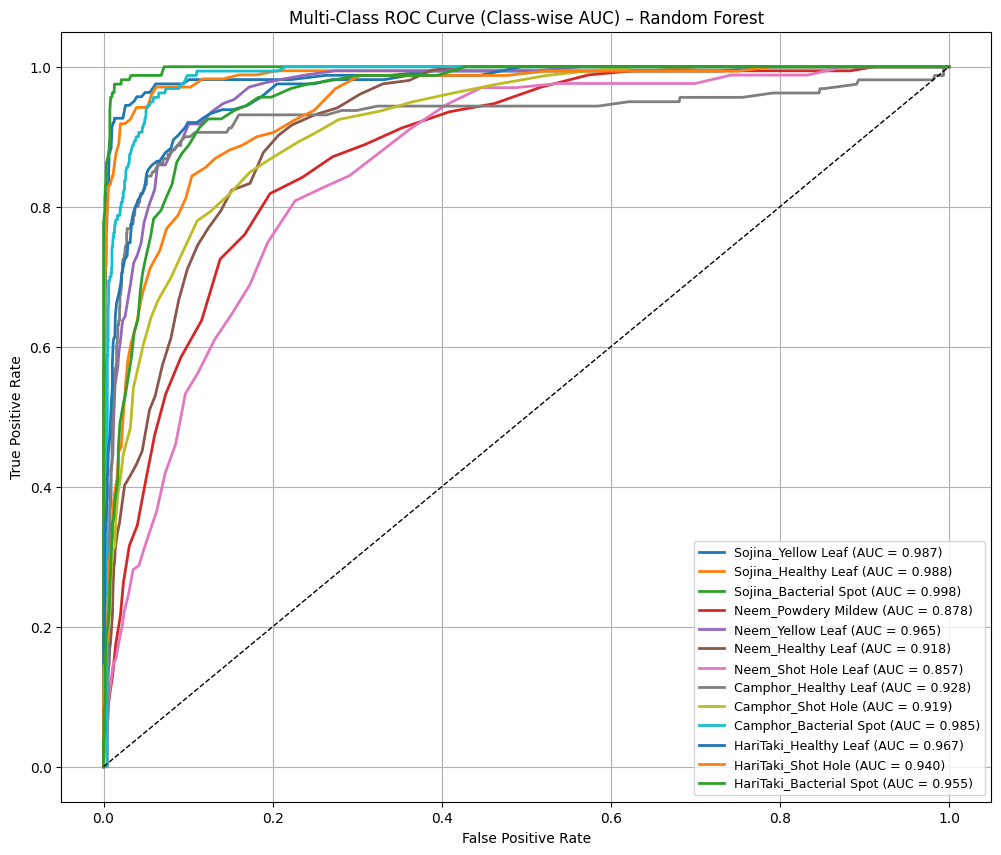


Multi-Class ROC Analysis Complete.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. PREPARE TRUE LABELS AND CLASS NAMES ---

# Assuming 'test_y' (true labels), 'NUM_CLASSES', and 'idx_to_class' are defined

# Binarize the true labels for multi-class ROC calculation
y_bin = label_binarize(test_y, classes=list(range(NUM_CLASSES)))

# FIX: idx_to_class is ALREADY a list of class names (strings), so we use it directly.
CLASS_NAMES = idx_to_class 


# ============================================================================
# 2. MULTI-CLASS ROC PLOTTING FUNCTION
# ============================================================================

def plot_multiclass_roc(model, model_name, test_X, y_bin, class_names):
    """Plots the ROC curve for a multi-class classifier."""
    
    # 1. Get probability scores
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(test_X)
    else:
        # Fallback for models like linear SVM if probability=False was used
        scores = model.decision_function(test_X)
        if scores.ndim == 1:
            scores = scores.reshape(-1,1)
    
    # Ensure scores are ready for AUC calculation (scores must match y_bin shape)
    if scores.shape[1] != NUM_CLASSES:
        print(f"Error: Score dimensions ({scores.shape[1]}) do not match NUM_CLASSES ({NUM_CLASSES}). Skipping ROC for {model_name}.")
        return

    # 2. Plotting loop
    plt.figure(figsize=(12, 10))
    for i in range(NUM_CLASSES):
        # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Use the correct class name for the label
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})"
        plt.plot(fpr, tpr, lw=2, label=label)

    # Plot the random chance line
    plt.plot([0,1],[0,1], "k--", lw=1)
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve (Class-wise AUC) – {model_name}")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    plt.show()

# ============================================================================
# 3. PLOT ROC FOR ALL TRAINED MODELS
# ============================================================================
# The 'classifiers' dictionary contains the trained models from Cell 8

for name, model in classifiers.items():
    print(f"Plotting ROC for {name}...")
    
    if not hasattr(model, "predict_proba") and not hasattr(model, "decision_function"):
        print(f"Warning: Model '{name}' does not support score prediction. Skipping.")
        continue
    
    if name == "SVM (RBF)" and not hasattr(model, "predict_proba"):
        print(f"Warning: SVM model '{name}' requires 'probability=True' during initialization to plot ROC. Skipping.")
        continue
        
    # Plot the ROC curve, passing the correctly defined CLASS_NAMES list
    plot_multiclass_roc(model, name, test_X, y_bin, class_names=CLASS_NAMES)

print("\nMulti-Class ROC Analysis Complete.")


================ MLP (Deep) =================
✔️ Overall Test Accuracy: 82.41%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          86.88
Camphor_Healthy Leaf            81.88
Camphor_Shot Hole               78.62
HariTaki_Bacterial Spot         70.81
HariTaki_Healthy Leaf           83.44
HariTaki_Shot Hole              75.62
Neem_Healthy Leaf               70.10
Neem_Powdery Mildew             73.68
Neem_Shot Hole Leaf             63.47
Neem_Yellow Leaf                94.74
Sojina_Bacterial Spot           98.14
Sojina_Healthy Leaf             97.67
Sojina_Yellow Leaf              98.77

📄 Classification Report:
                         precision  recall  f1-score   support
Sojina_Yellow Leaf           0.976   0.988     0.982   163.000
Sojina_Healthy Leaf          0.982   0.977     0.980   172.000
Sojina_Bacterial Spot        0.988   0.981     0.984   161.000
Neem_Powdery Mildew          0.685   0.737     0.710   171.000
Neem_Yellow Leaf        

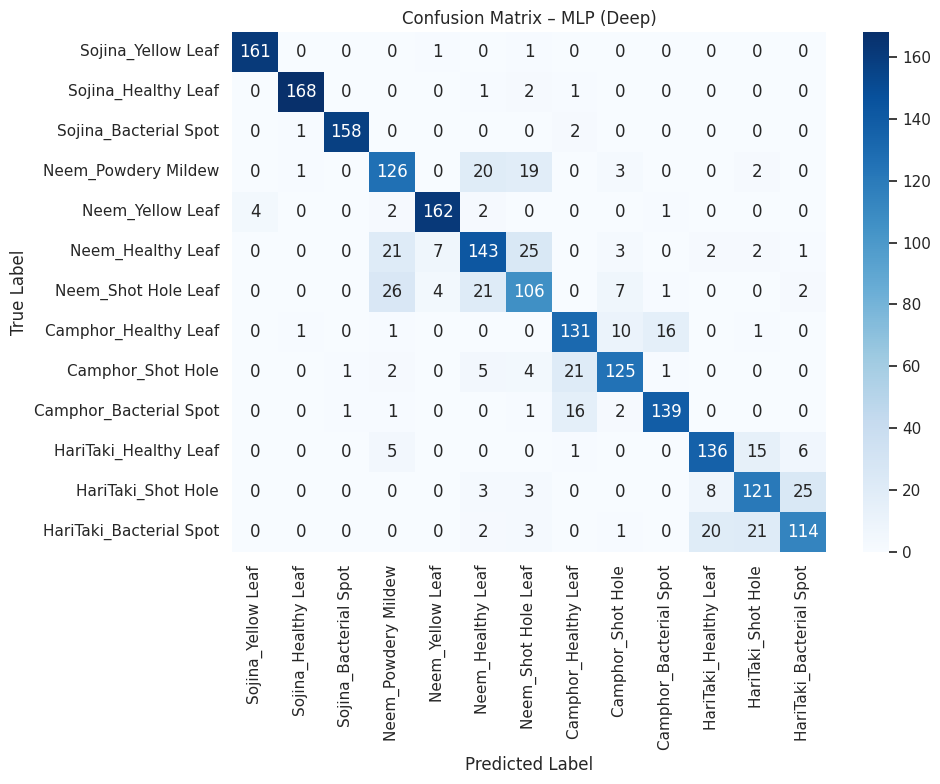


================ SVM (RBF) =================
✔️ Overall Test Accuracy: 80.89%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          91.25
Camphor_Healthy Leaf            83.12
Camphor_Shot Hole               71.70
HariTaki_Bacterial Spot         67.08
HariTaki_Healthy Leaf           79.14
HariTaki_Shot Hole              71.88
Neem_Healthy Leaf               70.59
Neem_Powdery Mildew             71.35
Neem_Shot Hole Leaf             59.88
Neem_Yellow Leaf                92.98
Sojina_Bacterial Spot           98.76
Sojina_Healthy Leaf             97.67
Sojina_Yellow Leaf              98.16

📄 Classification Report:
                         precision  recall  f1-score   support
Sojina_Yellow Leaf           0.970   0.982     0.976   163.000
Sojina_Healthy Leaf          0.977   0.977     0.977   172.000
Sojina_Bacterial Spot        0.988   0.988     0.988   161.000
Neem_Powdery Mildew          0.632   0.713     0.670   171.000
Neem_Yellow Leaf         

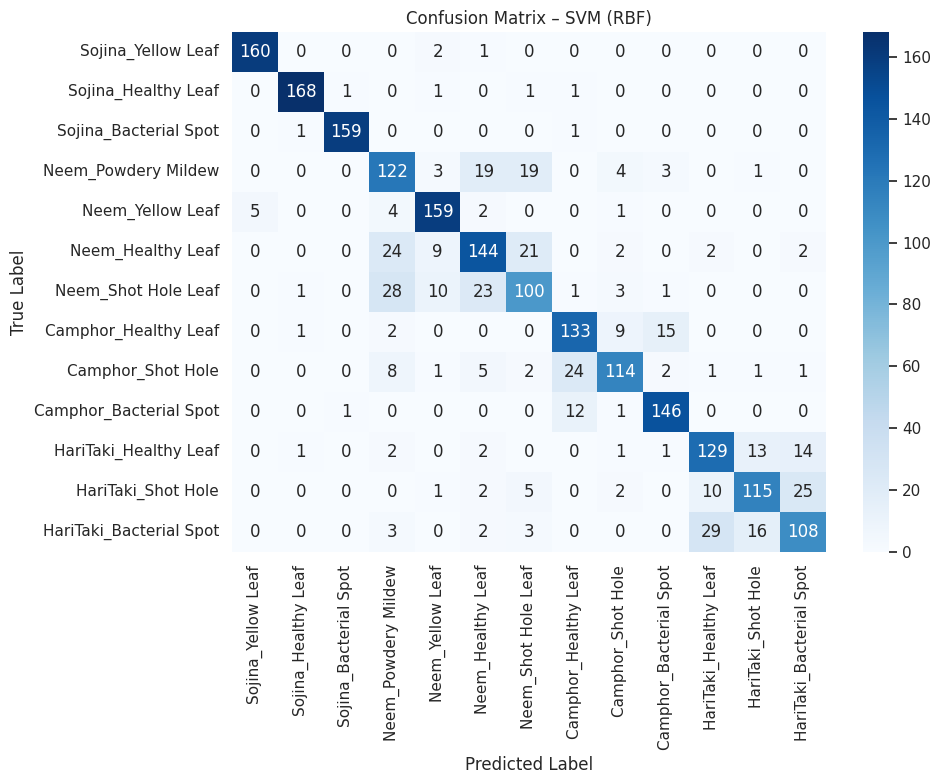


================ Decision Tree =================
✔️ Overall Test Accuracy: 37.29%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          50.62
Camphor_Healthy Leaf            49.38
Camphor_Shot Hole               23.90
HariTaki_Bacterial Spot         27.33
HariTaki_Healthy Leaf           39.88
HariTaki_Shot Hole              29.38
Neem_Healthy Leaf               21.57
Neem_Powdery Mildew             16.37
Neem_Shot Hole Leaf             25.15
Neem_Yellow Leaf                37.43
Sojina_Bacterial Spot           68.32
Sojina_Healthy Leaf             49.42
Sojina_Yellow Leaf              50.92

📄 Classification Report:
                         precision  recall  f1-score   support
Sojina_Yellow Leaf           0.532   0.509     0.520   163.000
Sojina_Healthy Leaf          0.452   0.494     0.472   172.000
Sojina_Bacterial Spot        0.719   0.683     0.701   161.000
Neem_Powdery Mildew          0.182   0.164     0.172   171.000
Neem_Yellow Leaf     

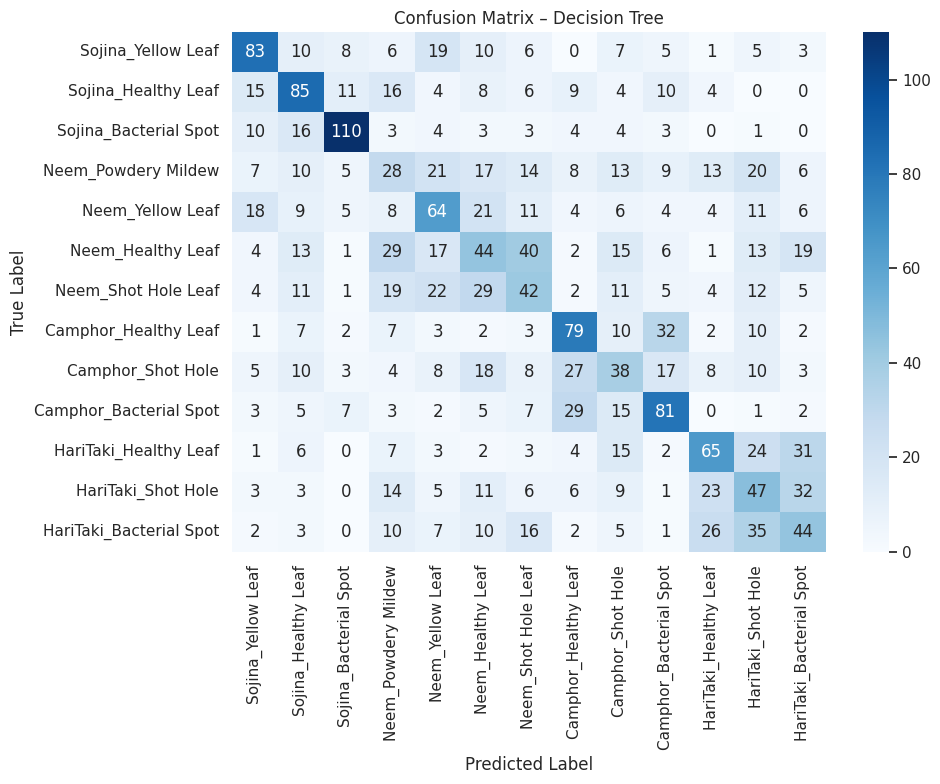


================ Random Forest =================
✔️ Overall Test Accuracy: 65.75%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          76.25
Camphor_Healthy Leaf            81.25
Camphor_Shot Hole               45.28
HariTaki_Bacterial Spot         55.28
HariTaki_Healthy Leaf           84.66
HariTaki_Shot Hole              53.75
Neem_Healthy Leaf               66.67
Neem_Powdery Mildew             30.99
Neem_Shot Hole Leaf             14.97
Neem_Yellow Leaf                69.59
Sojina_Bacterial Spot           95.65
Sojina_Healthy Leaf             88.95
Sojina_Yellow Leaf              92.64

📄 Classification Report:
                         precision  recall  f1-score   support
Sojina_Yellow Leaf           0.830   0.926     0.875   163.000
Sojina_Healthy Leaf          0.818   0.890     0.852   172.000
Sojina_Bacterial Spot        0.917   0.957     0.936   161.000
Neem_Powdery Mildew          0.491   0.310     0.380   171.000
Neem_Yellow Leaf     

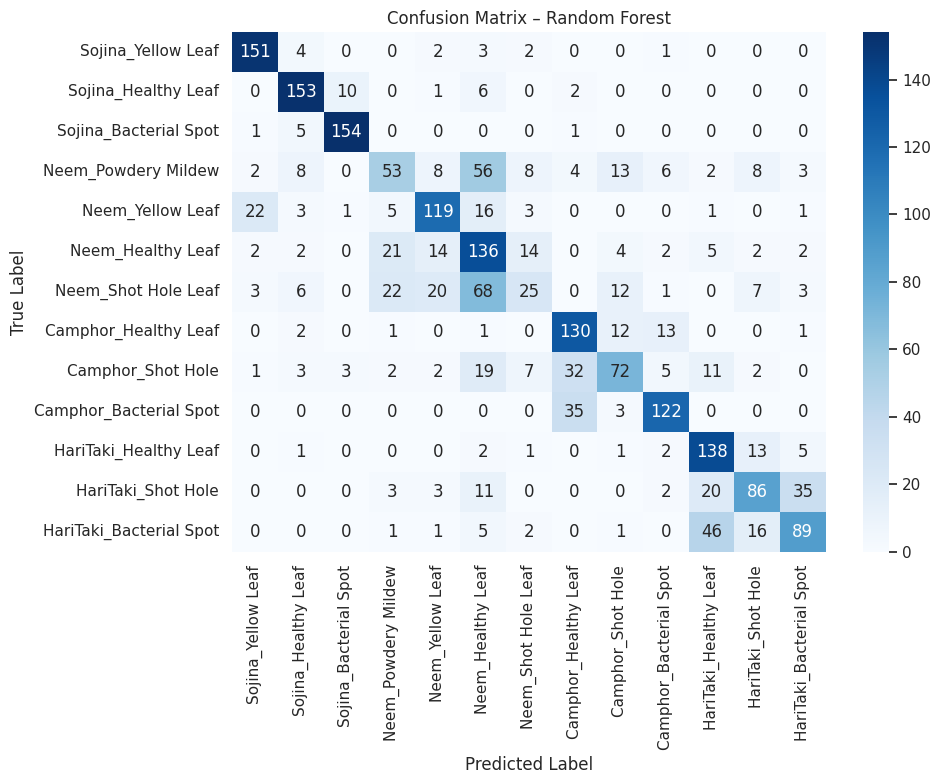


================ FINAL MODEL COMPARISON (MAE Features) ================
               Accuracy  Macro Precision  Macro Recall  Macro F1  Accuracy (%)
MLP (Deep)       0.8241           0.8261        0.8260    0.8257       82.4125
SVM (RBF)        0.8089           0.8107        0.8104    0.8095       80.8932
Decision Tree    0.3729           0.3744        0.3767    0.3749       37.2928
Random Forest    0.6575           0.6554        0.6584    0.6447       65.7459


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# --- Configuration Check ---
# Assuming 'classifiers', 'test_X', 'test_y', 'NUM_CLASSES', and 'class_to_idx' are defined

# Ensure the class names list is correctly extracted from the dictionary
CLASS_NAMES = list(class_to_idx.keys())


# ============================================================
# EVALUATION FOR ALL MODELS
# ============================================================
all_results = {}

for model_name, model in classifiers.items():

    print(f"\n================ {model_name} =================")

    # ------------------------------
    # 1️⃣ Predictions
    # ------------------------------
    # Predict the test features using the trained ML model
    preds = model.predict(test_X)

    # ------------------------------
    # 2️⃣ Overall Accuracy
    # ------------------------------
    overall_acc = accuracy_score(test_y, preds)
    print(f"✔️ Overall Test Accuracy: {overall_acc * 100:.2f}%")

    # ------------------------------
    # 3️⃣ Per-Class Accuracy
    # ------------------------------
    per_class_acc = {}
    for c in range(NUM_CLASSES):
        # Find indices where the true label matches class 'c'
        idx = np.where(test_y == c)[0]
        # Calculate accuracy only for that class
        class_acc = accuracy_score(test_y[idx], preds[idx])
        
        # Use the correct index-to-name mapping
        # Note: Since class_to_idx.keys() is not reliably ordered by index in older Python,
        # we assume it matches the order of the range(NUM_CLASSES) loop.
        class_name = CLASS_NAMES[c] 
        per_class_acc[class_name] = class_acc * 100

    df_acc = pd.DataFrame.from_dict(
        per_class_acc, orient='index', columns=['Accuracy (%)']
    ).sort_index()

    print("\n📌 Per-Class Accuracy:")
    print(df_acc.to_string(float_format="%.2f"))

    # ------------------------------
    # 4️⃣ Classification Report
    # ------------------------------
    print("\n📄 Classification Report:")
    report = classification_report(
        test_y,
        preds,
        target_names=CLASS_NAMES,
        digits=3,
        output_dict=True
    )
    df_report = pd.DataFrame(report).T
    print(df_report.round(3))

    # ------------------------------
    # 5️⃣ Macro Metrics
    # ------------------------------
    macro_precision = precision_score(test_y, preds, average="macro")
    macro_recall    = recall_score(test_y, preds, average="macro")
    macro_f1        = f1_score(test_y, preds, average="macro")

    print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
    print(f"🔹 Macro Recall:    {macro_recall:.3f}")
    print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

    # Save summary
    all_results[model_name] = {
        "Accuracy": overall_acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    }

    # ------------------------------
    # 6️⃣ Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(test_y, preds)
    

    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1.0)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xticks(rotation=90) # Rotate for better visibility with long names
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ============================================================
# FINAL SUMMARY COMPARISON
# ============================================================
df_summary = pd.DataFrame(all_results).T
df_summary["Accuracy (%)"] = df_summary["Accuracy"] * 100

print("\n================ FINAL MODEL COMPARISON (MAE Features) ================")
print(df_summary.round(4))

--- Starting Data Efficiency Test (Fractional Training) ---

🔹 Training with 1% labeled data (76 samples)
SVM Accuracy: 34.99%
Decision Tree Accuracy: 10.73%
Random Forest Accuracy: 15.79%
MLP Accuracy: 33.24%

🔹 Training with 5% labeled data (380 samples)
SVM Accuracy: 57.78%
Decision Tree Accuracy: 24.63%
Random Forest Accuracy: 43.09%
MLP Accuracy: 59.71%

🔹 Training with 10% labeled data (760 samples)
SVM Accuracy: 65.24%
Decision Tree Accuracy: 22.88%
Random Forest Accuracy: 52.21%
MLP Accuracy: 66.71%

🔹 Training with 25% labeled data (1900 samples)
SVM Accuracy: 71.50%
Decision Tree Accuracy: 30.48%
Random Forest Accuracy: 58.29%
MLP Accuracy: 74.22%

🔹 Training with 50% labeled data (3800 samples)
SVM Accuracy: 76.75%
Decision Tree Accuracy: 34.07%
Random Forest Accuracy: 63.40%
MLP Accuracy: 79.37%

Plotting Data Efficiency Results...


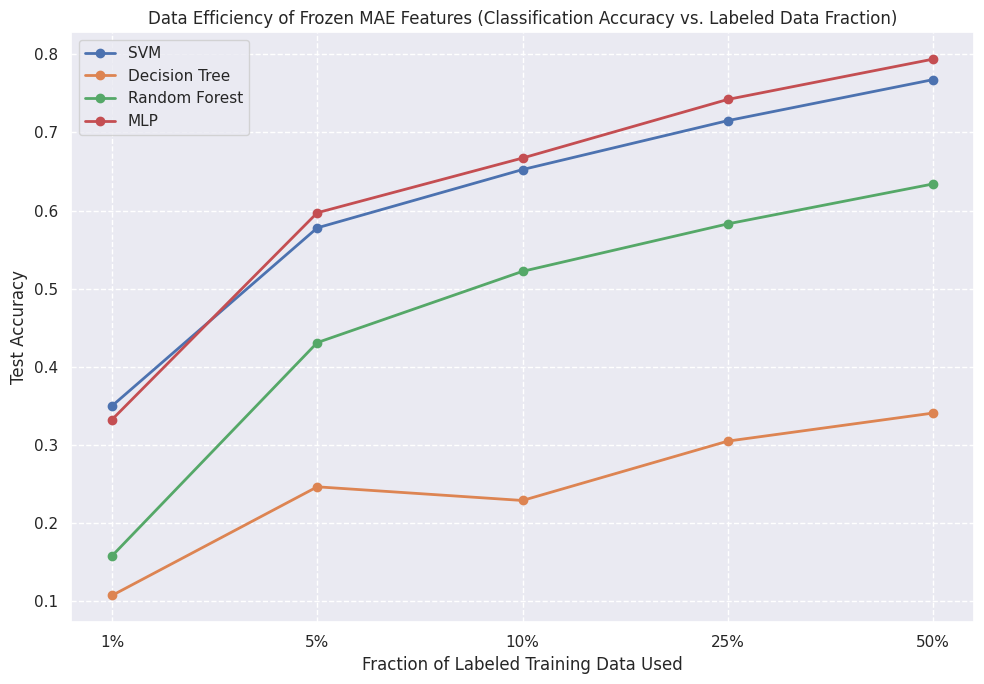


Data Efficiency Analysis Complete.


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------
# 1. Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
# n_train is the total number of training features extracted in Cell 8
n_train = train_X.shape[0] 

# Store results
results = {
    "SVM": [],
    "Decision Tree": [],
    "Random Forest": [],
    "MLP": []
}

# ------------------------------
# 2. Loop over fractions
# ------------------------------
print("--- Starting Data Efficiency Test (Fractional Training) ---")

for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    # Select a random subset of training indices
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    print(f"\n🔹 Training with {frac*100:.0f}% labeled data ({n_samples} samples)")

    # ---------- SVM ----------
    # Note: SVM training time can be long, especially for larger subsets
    svm = SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42)
    svm.fit(X_subset, y_subset)
    preds = svm.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["SVM"].append(acc)
    print(f"SVM Accuracy: {acc*100:.2f}%")

    # ---------- Decision Tree ----------
    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        random_state=42
    )
    dt.fit(X_subset, y_subset)
    preds = dt.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["Decision Tree"].append(acc)
    print(f"Decision Tree Accuracy: {acc*100:.2f}%")

    # ---------- Random Forest ----------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_subset, y_subset)
    preds = rf.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["Random Forest"].append(acc)
    print(f"Random Forest Accuracy: {acc*100:.2f}%")

    # ---------- MLP ----------
    mlp = MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42
    )
    mlp.fit(X_subset, y_subset)
    preds = mlp.predict(test_X)
    acc = accuracy_score(test_y, preds)
    results["MLP"].append(acc)
    print(f"MLP Accuracy: {acc*100:.2f}%")


# ------------------------------
# 3. Plotting the results
# ------------------------------
print("\nPlotting Data Efficiency Results...")
plt.figure(figsize=(10, 7))

x_labels = [f"{f*100:.0f}%" for f in fractions]
x_coords = np.arange(len(fractions))

for name, acc_list in results.items():
    plt.plot(x_coords, acc_list, marker='o', label=name, lw=2)

plt.xticks(x_coords, x_labels)
plt.title('Data Efficiency of Frozen MAE Features (Classification Accuracy vs. Labeled Data Fraction)')
plt.xlabel('Fraction of Labeled Training Data Used')
plt.ylabel('Test Accuracy')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

print("\nData Efficiency Analysis Complete.")